In [1]:
import matplotlib as mpl
import numpy as np
import sympy as sp
from matplotlib import pyplot as plt
from openfermion.config import EQ_TOLERANCE

from ofex.hamiltonian import heisenberg_1d_ring
from ofex.linalg.sparse_tools import diagonalization, collect_degen_eigspace_hierarchy, expectation
from ofex.operators import normalize_by_lcu_norm
from ofex.propagator import exact_rte, trotter_rte_by_si_ref

mpl.rc('text', usetex = True)

from ofex.classical_algorithms.funcapprox import uniform_inner_product, FunctionBasis, plot_functions, FourierBasis, \
    FirstChebyshevBasis
from ofex.hamiltonian_functions import hamiltonian_fourier_series


# 1. Function Approximation

Consider a function space equipped with an inner product $\braket{f,g}\in\mathbb{C}$ and the corresponding norm $\|f\|^2 = \braket{f, f}$, where the inner product satisfies:
  - **Linearity**: $\braket{f,ag_1+bg_2}=a\braket{f,g_1}+b\braket{f,g_2}\quad \forall~a, b \in \mathbb{C}$
  - **Symmetry**: $\braket{f, g} = \braket{g, f}^*$
  - **Positivity**: $\braket{f, f} \ge 0$, and $\braket{f, f} = 0$ iff $f=0$.

Given a finite set of basis functions $\mathcal{V}_n=\{v_k:k=1,\cdots, n\}$, we aim to solve the approximation problem such that a target function $f$ is approximated by the linear combination of the basis functions:
$$
    \min_{\vec{c}\in \mathbb{C}^n}\|f - g\|\quad \mathrm{s.t.}\quad g = \sum_{k=1}^n c_k v_k.
$$
Using the properties of inner products, it can be shown that the approximation problem is solvable by the following linear equation:
$$
    \mathbf{S}\vec{c}^{\star} = \vec{\mu} \quad \mathrm{where} \quad [\mathbf{S}]_{kl} = \braket{v_k,v_l}~\mathrm{and}~[\vec{\mu}]_k = \braket{v_k, f}.
$$
Furthermore, the resulting error is given as
$$
    \min_{\vec{c}}\|f-g\| = (\|f\|^2 - \vec{\mu}^\dagger \vec{c}^{\star})^{1/2}.
$$

Especially, when the $n$ basis functions are finitely chosen from the complete orthogonal set (such as Fourier and (normalized) Chebyshev poly series in the next section):
$$
    \mathcal{V}_n \subseteq \mathcal{V}_{\infty}\quad \braket{v_k, v_l} = \delta_{kl} \quad \forall v_k, v_l \in \mathcal{V}_{\infty}
$$
we have the error bound of
$$
    \|f-g\| = \left(\sum_{k=n+1}^{\infty} |\mu_k|^2 \right)^{1/2},
$$
because the orthonormality makes $\mathbf{S}=\mathbb{I}$ and $\vec{c}^{\star}=\vec{\mu}$, and the completeness ensures
$$
    f = \sum_{k=1}^{\infty} c^{\star}_k v_k
$$

Furthermore, the max norm residual,
$$
    \|f-g\|_{\infty} := \max_{x\in\mathcal{D}}|f(x)-g(x)| = \max_{x\in\mathcal{D}}\left| \sum_{k=n+1}^{\infty} \mu_k v_k(x)\right| \le \sum_{k=n+1}^{\infty} |\mu_k| \|v_k\|_\infty
$$
Note that the max norm is **not** derived from the function inner product since it lacks of linearity. Also, the orthonormality doesn't ensure the finite max norm.
$$
    \|v_k\|=1 \nRightarrow \|v_k\|_\infty < \infty
$$

## Example

Such definition and function approximation are included in `ofex.classical_algorithms.FunctionBasis`. The following example code includes a function approximation with a custom definition of function inner product and basis function:
$$
    \braket{f,g}_{\mathrm{u}} =\frac{1}{2}\int_{-1}^{1}f^*(x)g(x)dx,\quad \mathcal{V} = \{1, x^2, x^3, \sin \pi x\},
$$
and the target function is
$$
    f(x) = e^x
$$

In [2]:
# Custom function inner product performs uniform integral
def custom_inner_product(v1:sp.Expr, v2:sp.Expr) -> complex:
    prod = sp.simplify((v1.conjugate() * v2))
    syms = prod.free_symbols
    if len(syms) == 0:
        return complex(prod)
    elif len(syms) > 1:
        raise ValueError(f"There are redundant symbols {prod}, {syms}")
    x = list(syms)[0]
    integral = sp.integrate(prod, (x, -1, 1))
    return complex(integral / 2)

# Equivalently, you can use
# custom_inner_product = uniform_inner_product(x_max=1.0, numerical_integ=True)

# Custom basis functions
x = sp.Symbol('x')
custom_functions = [1, x**2, x**3, sp.sin(sp.pi * x)]

# Basis functions equipped with the inner product
custom_function_basis = FunctionBasis(custom_functions, custom_inner_product)

# overlap matrix S
print("Overlap matrix S:")
print(custom_function_basis.overlap_matrix)

Overlap matrix S:
[[1.        +0.j 0.33333333+0.j 0.        +0.j 0.        +0.j]
 [0.33333333+0.j 0.2       +0.j 0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.14285714+0.j 0.12480068+0.j]
 [0.        +0.j 0.        +0.j 0.12480068+0.j 0.5       +0.j]]


Optimal function: 1.25304303128619*x**3 + 0.536721525971059*x**2 + 0.366564939695582*sin(pi*x) + 0.996294018320115
Residual error norm: 0.024320712684105256


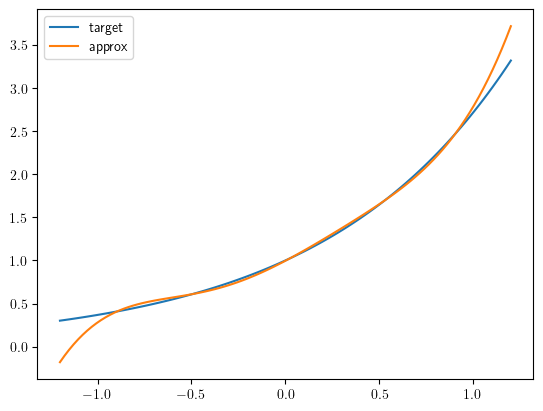

[<Axes: >]

In [3]:
# Target function
f = sp.exp(x)

# Perform the optimization
opt_g, coeffs, diff_norm = custom_function_basis.l2_minimization(f)

print(f"Optimal function: {opt_g}")
print(f"Residual error norm: {diff_norm}")
plot_functions({"target": f, "approx": opt_g}, x, x_points=np.linspace(-1.2, 1.2, 100))



# 2. Function Approximation Examples

## 2-1. Fourier Series

Consider the following basis functions, and the inner product of
$$
    \mathcal{V}^{(\mathrm{f})}_n:=\{v_k^{(\mathrm{f})}(x)=e^{ik\pi x}: k=-n,\cdots,n\}\quad\braket{f,g}_{\mathrm{u}} =\frac{1}{2}\int_{-1}^{1}f^*(x)g(x)dx,
$$
where its implementation is given in `ofex.classical_algorithms.uniform_inner_product` with `x_max=1.0`.

We have a nice orthogonality of these basis and inner product:
$$
    \braket{v_k^{(\mathrm{f})},v_l^{(\mathrm{f})}}_{\mathrm{u}}=\delta_{kl},
$$
which makes $\mathbf{S}=\mathbb{I}$ and $\vec{c}^{\star} = \vec{\mu}$. Therefore, the famous Fourier series formula is derived:
$$
    c_k = \braket{v_k^{(\mathrm{f})}, f} = \frac{1}{2}\int_{-1}^{1} f(x) e^{-ik\pi x} dx.
$$

The following example shows the Fourier series approximation of $f(x)=e^{-4x^2}$ with the basis function of $\mathcal{V}_n^{(\mathrm{f})}$ with $n=4$.

In [4]:
fourier_functions = [sp.exp(1j * np.pi * x * k) for k in range(-4, 5)]
fourier_function_basis = FunctionBasis(fourier_functions, uniform_inner_product(x_max=1.0, numerical_integ=True))
print("Overlap matrix S (Fourier basis):")
with np.printoptions(precision=1, linewidth=300):
    print(fourier_function_basis.overlap_matrix)
print(f"Is close to identity matrix?: {np.allclose(fourier_function_basis.overlap_matrix, np.eye(fourier_function_basis.n_basis))}")


Overlap matrix S (Fourier basis):
[[ 1.0e+00+0.j -9.0e-15+0.j  3.9e-15+0.j -3.2e-15+0.j  2.2e-15+0.j -1.6e-15+0.j  1.8e-15+0.j -1.5e-15+0.j  1.9e-15+0.j]
 [-9.0e-15+0.j  1.0e+00+0.j  1.2e-15+0.j  5.0e-16+0.j  2.1e-17+0.j -3.2e-16+0.j -1.8e-16+0.j -1.3e-16+0.j -1.5e-15+0.j]
 [ 3.9e-15+0.j  1.2e-15+0.j  1.0e+00+0.j -2.1e-15+0.j  4.7e-16+0.j  3.2e-17+0.j  4.7e-16+0.j -1.8e-16+0.j  1.8e-15+0.j]
 [-3.2e-15+0.j  5.0e-16+0.j -2.1e-15+0.j  1.0e+00+0.j  9.9e-16+0.j -9.8e-16+0.j  3.2e-17+0.j -3.2e-16+0.j -1.6e-15+0.j]
 [ 2.2e-15+0.j  2.1e-17+0.j  4.7e-16+0.j  9.9e-16+0.j  1.0e+00+0.j  9.9e-16+0.j  4.7e-16+0.j  2.1e-17+0.j  2.2e-15+0.j]
 [-1.6e-15+0.j -3.2e-16+0.j  3.2e-17+0.j -9.8e-16+0.j  9.9e-16+0.j  1.0e+00+0.j -2.1e-15+0.j  5.0e-16+0.j -3.2e-15+0.j]
 [ 1.8e-15+0.j -1.8e-16+0.j  4.7e-16+0.j  3.2e-17+0.j  4.7e-16+0.j -2.1e-15+0.j  1.0e+00+0.j  1.2e-15+0.j  3.9e-15+0.j]
 [-1.5e-15+0.j -1.3e-16+0.j -1.8e-16+0.j -3.2e-16+0.j  2.1e-17+0.j  5.0e-16+0.j  1.2e-15+0.j  1.0e+00+0.j -9.0e-15+0.j]
 [ 1.9

Optimal function: 0.241001633094851*exp(3.14159265358979*I*x) + 0.0361321000219835*exp(6.28318530717959*I*x) + 0.00273791646612104*exp(9.42477796076938*I*x) - 0.000681948458616217*exp(12.5663706143592*I*x) + 0.44104069538121 - 0.000681948458616217*exp(-12.5663706143592*I*x) + 0.00273791646612104*exp(-9.42477796076938*I*x) + 0.0361321000219835*exp(-6.28318530717959*I*x) + 0.241001633094851*exp(-3.14159265358979*I*x)
Residual error norm: 0.0011127648659311233


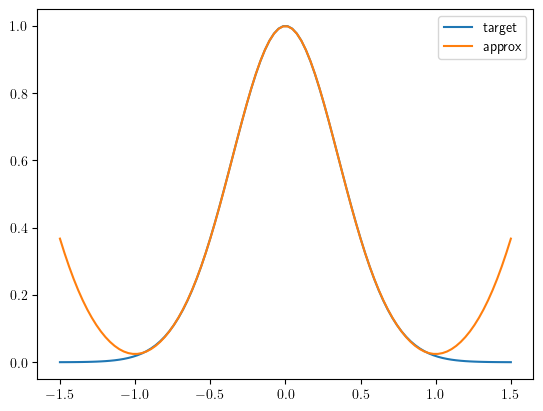

[<Axes: >]

In [5]:
f = sp.exp(-4 * x**2)
opt_g, coeffs, diff_norm = fourier_function_basis.l2_minimization(f)

print(f"Optimal function: {opt_g}")
print(f"Residual error norm: {diff_norm}")
plot_functions({"target": f, "approx": opt_g}, x, x_points=np.linspace(-1.5, 1.5, 100))

Since our inner product is defined only over the interval $[−1,1]$, the approximation deviates from the target function for $|x|>1$. Additionally, because the basis function is periodic, the resulting approximating function is also periodic.

We also can use `FourierBasis` class doing the same thing but reduced computational overhead when calculating the overlap matrix leveraged by the orthogonality.

Optimal function: 0.241001633094851*exp(3.14159265358979*I*x) + 0.0361321000219832*exp(6.28318530717959*I*x) + 0.00273791646612113*exp(9.42477796076938*I*x) - 0.000681948458616212*exp(12.5663706143592*I*x) + 0.441040695381211 - 0.000681948458616212*exp(-12.5663706143592*I*x) + 0.00273791646612113*exp(-9.42477796076938*I*x) + 0.0361321000219832*exp(-6.28318530717959*I*x) + 0.241001633094851*exp(-3.14159265358979*I*x)
Residual error norm: 0.0011127648658313517


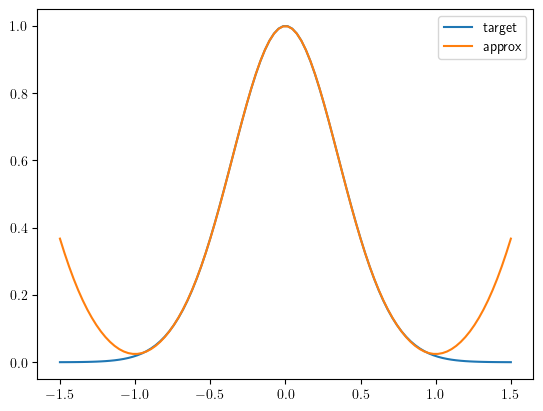

[<Axes: >]

In [6]:
fourier_function_basis = FourierBasis(4, numerical_integ=True)
opt_g, coeffs, diff_norm = fourier_function_basis.l2_minimization(f)

print(f"Optimal function: {opt_g}")
print(f"Residual error norm: {diff_norm}")
plot_functions({"target": f, "approx": opt_g}, x, x_points=np.linspace(-1.5, 1.5, 100))

## 2-2. Fourier Series with Higher-Order Derivatives

Consider the following basis:
$$
    \mathcal{V}_{n,d}^{(\mathrm{f})} = \bigcup_{l=0}^{d}\{x^le^{ik\pi x}:k=-n,\cdots,n\}.
$$
Each basis function has form of a product of monomial and complex exponentials. Also, $d=0$ reduces to the regular Fourier basis.
Note that the basis functions are no longer orthogonal.

In the following example, we observe how $\mathcal{V}_{n,d}^{(\mathrm{f})}$ for $d=0,\cdots,3$ approximates the following target function:
$$
    f(x) = x e^{-4x^2}
$$

In [7]:
min_harmonics = 1
max_harmonics = 10
max_deriv = 3

f = x * sp.exp(-4 * x**2)

deriv_fourier = FourierBasis(max_harmonics, deriv_order=max_deriv, numerical_integ=True)
opt_result = dict()
for d in range(max_deriv + 1):
    opt_result[d] = deriv_fourier.gradual_l2_minimization(f, n_min=min_harmonics, n_max=max_harmonics, max_deriv_order=d)

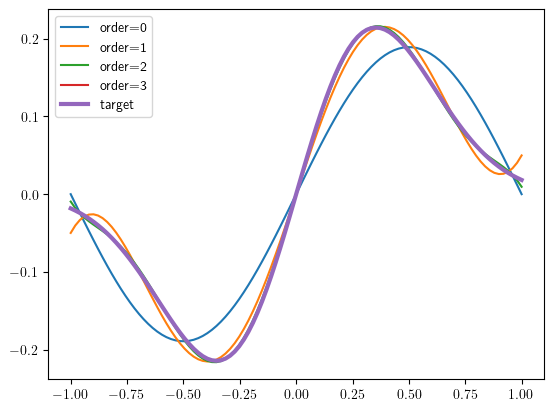

[<Axes: >]

In [8]:
sample_n = 2
func_list = {f"order={d}": opt_result[d][sample_n][0] for d in range(max_deriv + 1)}
func_list["target"] = f
plot_functions(func_list, x, x_points=np.linspace(-1.0, 1.0, 100), plot_options={"target": {"linewidth": 3.0}})

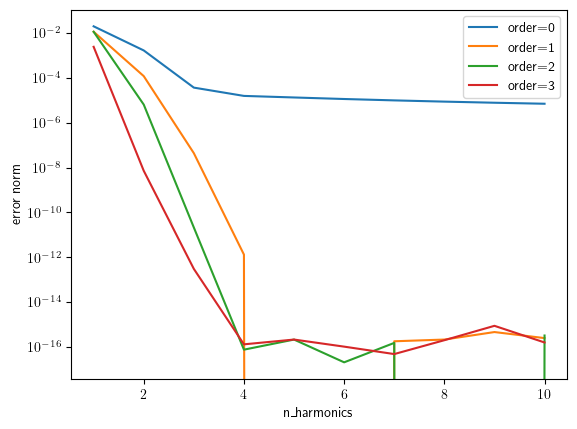

In [9]:
n_list = list(range(min_harmonics, max_harmonics+1))
for d in range(max_deriv + 1):
    diff_norm = np.array([opt_result[d][n][2] for n in n_list])
    assert np.allclose(diff_norm.imag, 0.0)
    diff_norm = diff_norm.real
    plt.plot(n_list, diff_norm, label=f"order={d}")
plt.legend()
plt.xlabel("n_harmonics")
plt.ylabel("error norm")
plt.yscale("log")

The Fourier series with higher order derivatives makes the error norm converges much faster.

## 2-3. Chebyshev Series

Consider the following Chebyshev polynomial basis and inner product weighted by $(1-x^2)^{-1/2}$:
$$
    \mathcal{V}_n^{(\mathrm{c})} = \{T_k(x):k=0,\cdots,n\}\quad\braket{f,g}_{\cup}:=\int_{-1}^{1}\frac{f^*(x)g(x)}{\sqrt{1-x^2}}dx.
$$

Then we have the following orthogonality:
$$
    \braket{T_{k}, T_{l}}=\begin{cases}
        0 \quad &k\neq l\\
        \pi \quad &k=l=0\\
        \pi/2 \quad &k=l\neq 0
    \end{cases}
$$

The following example approximates the following target function
$$
    f(x) = xe^{-4x^2}
$$

In [10]:
n_cheby = 10
cheby = FirstChebyshevBasis(n_cheby, numerical_integ=True, debug=True)

f = x * sp.exp(-4 * x**2)

opt_results_cheby = cheby.gradual_l2_minimization(f)

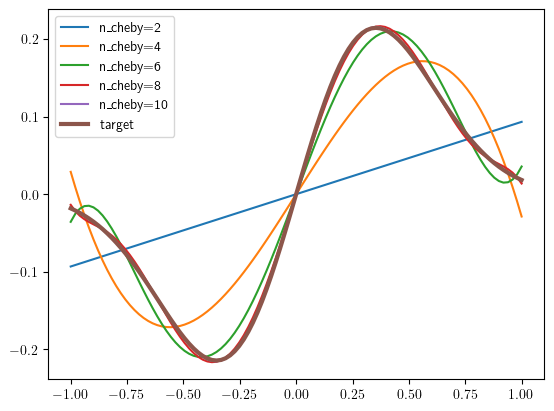

[<Axes: >]

In [11]:
select_n = [2,4,6,8,10]
func_list = {f"n_cheby={n}": opt_results_cheby[n][0] for n in select_n}
func_list["target"] = f
plot_functions(func_list, x, x_points=np.linspace(-1.0, 1.0, 100), plot_options={"target": {"linewidth": 3.0}})

Text(0, 0.5, 'error norm')

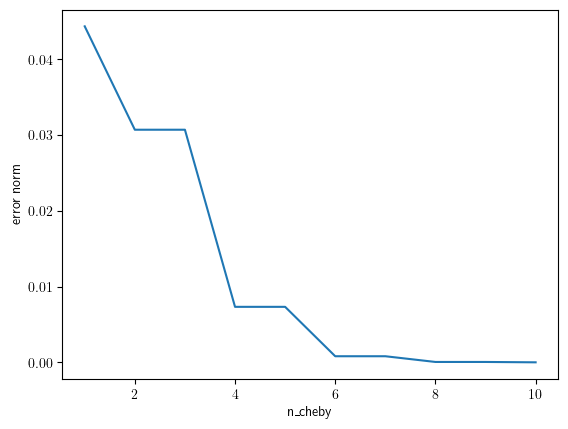

In [12]:
n_list = list(range(1, n_cheby+1))
diff_norm = np.array([opt_results_cheby[n][2] for n in n_list])
assert np.allclose(diff_norm.imag, 0.0)
diff_norm = diff_norm.real
plt.plot(n_list, diff_norm)
plt.xlabel("n_cheby")
plt.ylabel("error norm")

# 3. Regularized Approximation

Let's assume that approximating a function $f$ with the basis of $\{v_k\}$ and their inner product of $\braket{\cdot, \cdot}$, produces an exact optimal coefficients $\vec{c}$. After the optimization, if only the erroneous accesses to $v_k$, $\tilde{v}_k$, are possible, we have the following error bound by (***Let assume that the first inequality holds***):
$$
\begin{split}
    \|\tilde{g}(x;\vec{c}) - f(x)\| \le& \left[\|g(x;\vec{c}) - f(x)\|^2 + \|\tilde{g}(x;\vec{c}) - g(x;\vec{c})\|^2\right]^{1/2}\\
    \le& \left[ \|f(x)\|^2 +\vec{c}^{\dagger}\mathbf{S}\vec{c} - (\vec{c}^{\dagger}\vec{\mu}+\vec{\mu}^{\dagger}\vec{c}) + \vec{c}^{\dagger}\mathbf{S}_{\epsilon}\vec{c}\right]^{1/2}\\
    \le& \left[ \|f(x)\|^2 +\vec{c}^{\dagger}\left(\mathbf{S}+\mathrm{diag}\left(\vec{\epsilon}^2\right)\right)\vec{c} - (\vec{c}^{\dagger}\vec{\mu}+\vec{\mu}^{\dagger}\vec{c})\right]^{1/2}
\end{split}
$$
where $\epsilon_k(x) = \tilde{v}_k(x) - v_k(x)$, $[\mathbf{S}_{\epsilon}]_{kl}=\braket{\epsilon_k, \epsilon_l}$ and a spectral bound of $\|\mathbf{S}_{\epsilon}\|_{2}\le\mathrm{diag}(\vec{\epsilon^2}):=\mathrm{diag}(\epsilon_1^2,\cdots \epsilon_N^2)$ is used.
Minimizing the error bound is reduced to the following linear equation:
$$
    (\mathbf{S}+\mathrm{diag}(\vec{\epsilon}^2))\vec{c}=\vec{\mu}.
$$

The corresponding optimization is implemented in `FunctionBasis.l2_minimization_regularized` method.

We demonstrate an example of approximating $f(x)=x$ for $x\in[-1,1]$ with Fourier basis.
And then, we combine the resulting coefficients and the erroneous basis functions with gaussian noises.


In [13]:
np.random.seed(42)

f = x * sp.exp(-100 * x**2)
n_harmonics = 10
epsilon = 0.5

fb = FourierBasis(n_harmonics, numerical_integ=True, sym_x=x)
l2_min, l2_min_coeff, l2_min_diff = fb.l2_minimization(f)
reg2_min, reg2_coeff, reg2_diff = fb.l2_minimization_regularized(f, reg_coeff=epsilon)

err_l2 = np.linalg.norm(l2_min_coeff, ord=1) * epsilon
err_reg2 = np.linalg.norm(reg2_coeff, ord=1) * epsilon


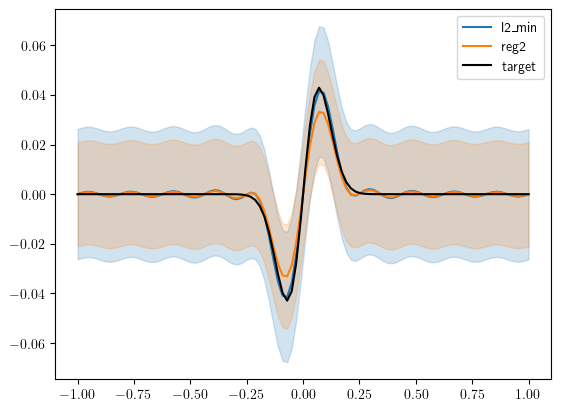

[<Axes: >]

In [14]:
plot_functions({"l2_min": l2_min,
                "reg2": reg2_min,
                "target": f},
               x,
               range_plot={"l2_min": (-err_l2, err_l2),
                           "reg2": (-err_reg2, err_reg2)},
               plot_options={"target": {"color": "black"}})

# 4. Hamiltonian Function

Given Fourier series, $g(x)=\sum_{k=-N}^{N}c_k e^{ik\pi x}$ with $|g(x)|\le 1$ for all $x\in[-1,1]$, GQSP ([arXiv:2308.01501](https://arxiv.org/abs/2308.01501)) implements $g(\hat{H})$.
The following code enables to simulate $g(\hat{H})$ by equipping the exact propagator $e^{i\hat{H}\pi}$ or its trotterization.

In [15]:
# Prepare Fourier Series
f = x * sp.exp(-50 * x**2)
fb = FourierBasis(6, numerical_integ=True, sym_x=x)
g, l2_min_coeff, _ = fb.l2_minimization(f)
d_omega = np.diff(fb.omega_list)[0]

# Prepare Hamiltonian, propagator, and trotterized propagator
n_qubits = 8
n_trotter = 1
assert np.isclose(d_omega, np.pi)
ham = heisenberg_1d_ring(n_qubits)
ham, norm = normalize_by_lcu_norm(ham, level=1)
rte = exact_rte(ham, t=d_omega)
trot_rte = trotter_rte_by_si_ref(ham, d_omega, n_qubits, n_trotter)

# Hamiltonian Function
g_ham = hamiltonian_fourier_series(l2_min_coeff, fb.omega_list, rte)
g_ham_trotter = hamiltonian_fourier_series(l2_min_coeff, fb.omega_list, trot_rte)

In [16]:
# Diagonalize the Hamiltonian
ham_eigval, ham_eigvec = diagonalization(ham, n_qubits, sparse_eig=False)
assert np.allclose(ham_eigval.imag, 0.0)
ham_eigval = ham_eigval.real
ham_eigspace = collect_degen_eigspace_hierarchy(ham_eigval, ham_eigvec)

# Diagonalize the Hamiltonian function with the exact rte and trotter
g_ham_eigval_quantum, g_ham_eigvec_quantum = np.linalg.eig(g_ham.toarray())
g_ham_trotter_eigval, _ = np.linalg.eig(g_ham_trotter.toarray())

# Classical calculation of eig function
f_ham_eigval = sp.lambdify(x, f, "numpy")(ham_eigval)
f_ham_eigval_dict = {ev: f_ev for ev, f_ev in zip(ham_eigval, f_ham_eigval)}

g_ham_eigval_classical = sp.lambdify(x, g, "numpy")(ham_eigval)
assert np.allclose(g_ham_eigval_classical.imag, 0.0)
g_ham_eigval_classical = g_ham_eigval_classical.real
g_ham_true_eigval_classical_dict = {ev: g_ev for ev, g_ev in zip(ham_eigval, g_ham_eigval_classical)}

In [17]:
# Compare
idx_g_checked = list()
sorted_degen_eigval = sorted(ham_eigspace.keys())
expct_gham, expct_gham_trotter = list(), list()
for eigval in sorted_degen_eigval:
    eigspace = ham_eigspace[eigval]
    expct_gham_now = expectation(g_ham, eigspace[:, 0])
    for i in range(1, eigspace.shape[1]):
        assert np.isclose(expct_gham_now, expectation(g_ham, eigspace[:, i]))
    expct_gham.append(expct_gham_now.real)
    expct_gham_trotter.append(expectation(g_ham_trotter, eigspace[:, 0]))

    g_eigval = g_ham_true_eigval_classical_dict[eigval]

    q, _ = np.linalg.qr(eigspace)
    prj = q @ q.T.conj()

    idx_g_now = list()
    for idx_g, g_eigval_q in enumerate(g_ham_eigval_quantum):
        if idx_g in idx_g_checked:
            continue
        v = g_ham_eigvec_quantum[:, idx_g]
        pv = prj @ v
        prj_check = np.allclose(pv, v, atol=EQ_TOLERANCE)
        val_check = np.isclose(g_eigval, g_eigval_q, atol=EQ_TOLERANCE)
        if prj_check or val_check:
            assert prj_check and val_check
            idx_g_checked.append(idx_g)
            idx_g_now.append(idx_g)
    assert len(idx_g_now) > 0
assert len(idx_g_checked) == len(g_ham_eigval_quantum)

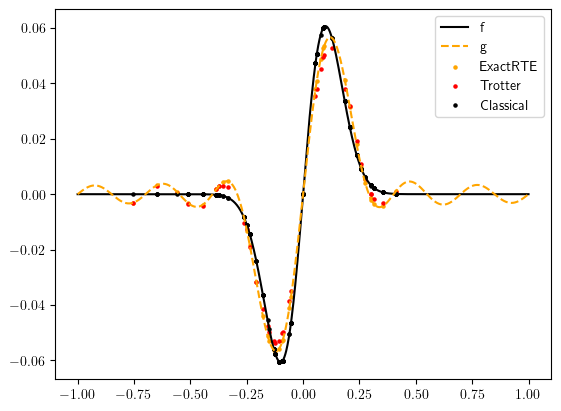

In [18]:
# Plot
expct_gham = np.array(expct_gham)
expct_gham_trotter = np.array(expct_gham_trotter)
assert np.allclose(expct_gham.imag, 0.0)
assert np.allclose(expct_gham_trotter.imag, 0.0)
expct_gham = expct_gham.real
expct_gham_trotter = expct_gham_trotter.real

x_points = np.linspace(-1.0, 1.0, 1000)
y_points_f = sp.lambdify(x, f, "numpy")(x_points)
y_points_g = sp.lambdify(x, g, "numpy")(x_points)
assert np.allclose(y_points_f.imag, 0.0)
assert np.allclose(y_points_g.imag, 0.0)
y_points_f = y_points_f.real
y_points_g = y_points_g.real

plt.plot(x_points, y_points_f, label="f", color="black")
plt.plot(x_points, y_points_g, label="g", color="orange", linestyle="dashed")

plt.scatter(sorted_degen_eigval, expct_gham,
            s=5.0, label="ExactRTE", color="orange")
plt.scatter(sorted_degen_eigval, expct_gham_trotter,
            s=5.0, label="Trotter", color="red")
plt.scatter(list(f_ham_eigval_dict.keys()), list(f_ham_eigval_dict.values()),
            s=5.0, label="Classical", color="black")
# plt.scatter(list(g_ham_true_eigval_classical_dict.keys()), list(g_ham_true_eigval_classical_dict.values()), label="Classical_Approx")
plt.legend()
plt.show()
